In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch 
from GaNN.models.GaNN import GaNN 
from GaNN.train.train import train_ien

%load_ext autoreload
%autoreload 2

# Using hypernetworks for optimal transport 

Given two distributions, P and Q, the goal of optimal transport is to learn a transport function that transforms P to Q, typically with some cost constraint. 

For this example, we'll use two 2-d Gaussian distributions as P and Q. 

In [80]:
# Define the parameters for the source distribution P
mu_P = np.array([0, 0])  # Mean vector
Sigma_P = np.array([[1, 0.4],
                    [0.4, 1]])  # Covariance matrix

# Define the parameters for the target distribution Q
mu_Q = np.array([5, 5])  # Mean vector
Sigma_Q = np.array([[2, 0],
                    [0, 2]])  # Covariance matrix

n_samples = 1000

P = np.random.multivariate_normal(mu_P, Sigma_P, n_samples)
Q = np.random.multivariate_normal(mu_Q, Sigma_Q, n_samples)

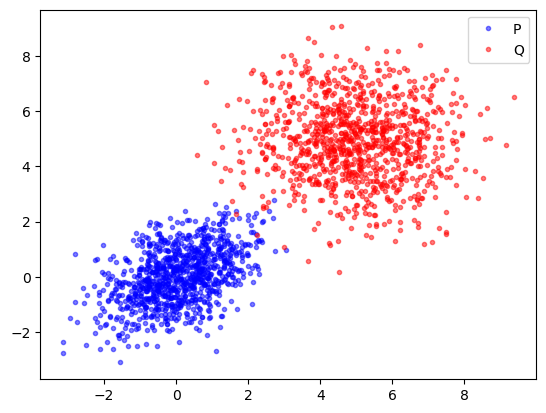

In [81]:
plt.figure()
plt.plot(*P.T, 'b.', alpha=0.5, label='P')
plt.plot(*Q.T, 'r.', alpha=0.5, label='Q')
plt.legend()
plt.show()

In [90]:
x = torch.tensor(P, dtype=torch.float32)
y = torch.tensor(Q, dtype=torch.float32)

model, losses = train_ien(x,y, loss_fn='edl+Tcost', model_kwargs={'hidden_channels':100, 
                                                               'layers':2, 
                                                               'gaussian_channels':10, 
                                                               'width':25, 
                                                               'nonlin':'elu',
                                                               'norm':'none'},
                        lr=1e-3, batch_size=500, num_epochs=1000, compile=False, nsamples=25)



In [91]:
yhat = model(x, samples=250)

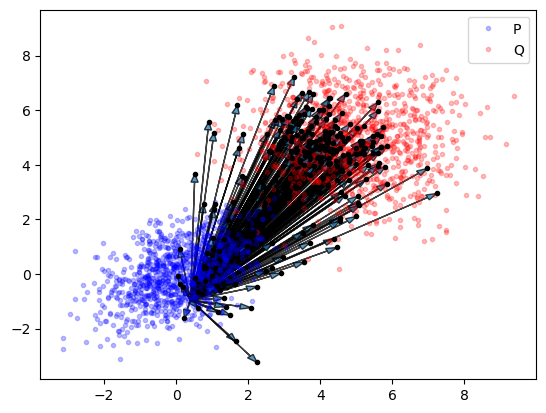

In [92]:
plt.figure()
plt.plot(*P.T, 'b.', alpha=0.25, label='P')
plt.plot(*Q.T, 'r.', alpha=0.25, label='Q')

# plot the transport function(s) for one observation 
obs_idx = 8
xx = x[obs_idx]
for i in range(yhat.size(0)): 
    yyhat = yhat[i, obs_idx, :]
    plt.arrow(xx[0].item(), xx[1].item(), yyhat[0].item() - xx[0].item(), yyhat[1].item()-xx[1].item(), head_width=0.2, length_includes_head=True, alpha=0.75)
    plt.plot(yyhat[0].item(), yyhat[1].item(), 'k.')

plt.legend()
plt.show()

In [75]:
def get_mode(data, bins=25):
    counts, bin_edges = np.histogram(data, bins=bins)
    max_count_index = np.argmax(counts)
    mode = (bin_edges[max_count_index] + bin_edges[max_count_index + 1]) / 2
    return mode

In [76]:
yhat = model(x, samples=1000)
# shape (nsamples, nobs, nfeatures)

In [77]:
# maybe we use a post hoc selection method? choose the prediction weight based on the one that minimizes the cost function?
    # that would just select all the smallest transports

# we could maybe do it in stage wise where first we learn *possible* transport functions, then we learn f(x) = z that minimizes the cost function 

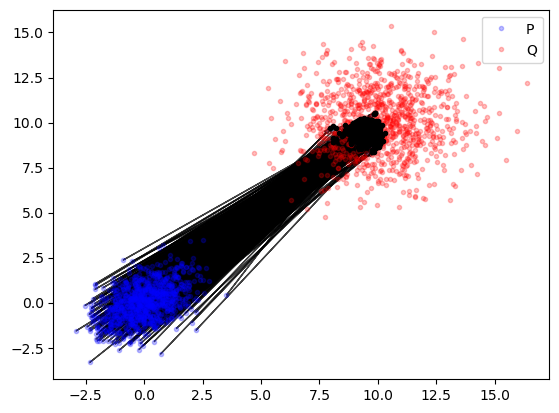

In [79]:
# what is the most propable or average transport function per obs? are they unique?

plt.figure()
plt.plot(*P.T, 'b.', alpha=0.25, label='P')
plt.plot(*Q.T, 'r.', alpha=0.25, label='Q')

# plot the average transport function for each obs 
yhat_mu = yhat.mean(0).detach().cpu().numpy()
for i in range(yhat.size(1)): 
    yyhat = (get_mode(yhat[:, i, 0].detach().cpu().numpy()), get_mode(yhat[:, i, 1].detach().cpu().numpy()))
    #yyhat = yhat_mu[i]
    xx = x[i].detach().cpu().numpy()
    plt.arrow(xx[0].item(), xx[1].item(), yyhat[0].item() - xx[0].item(), yyhat[1].item()-xx[1].item(), head_width=0.2, length_includes_head=True, alpha=0.75)
    plt.plot(yyhat[0].item(), yyhat[1].item(), 'k.')

plt.legend()
plt.show()